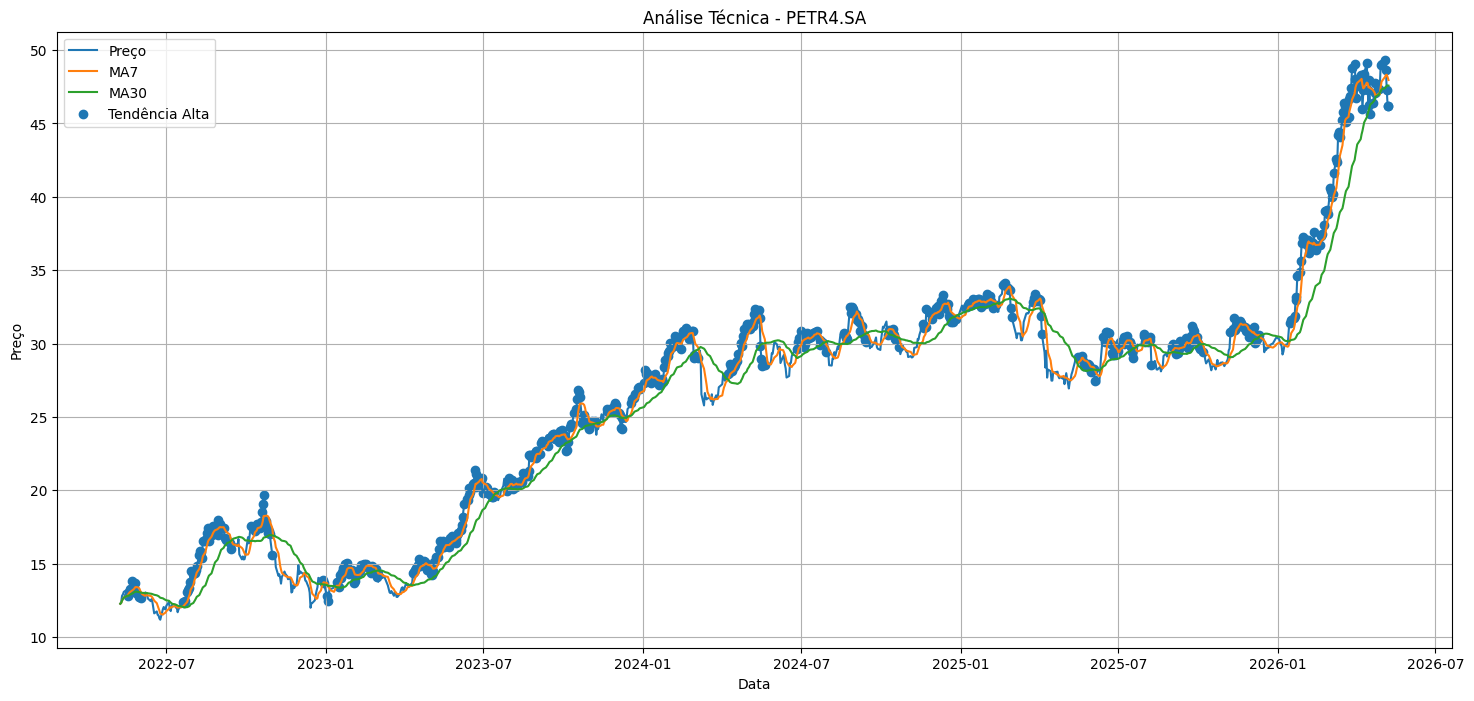

In [45]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

base_path = Path().absolute().parent
db_path = base_path / "data" / "financial.br_data.db"

conn = sqlite3.connect(str(db_path))

ticker = "PETR4.SA"

query = f"""
SELECT date, close, ma7, ma30
FROM gold_metrics
WHERE ticker = '{ticker}'
ORDER BY date
"""

df = pd.read_sql_query(query, conn)
conn.close()

df["date"] = pd.to_datetime(df["date"])

plt.figure(figsize=(18, 8))

plt.plot(df["date"], df["close"], label="Preço")
plt.plot(df["date"], df["ma7"], label="MA7")
plt.plot(df["date"], df["ma30"], label="MA30")

# cruzamento
cross = df[df["ma7"] > df["ma30"]]

plt.scatter(
    cross["date"],
    cross["close"],
    label="Tendência Alta"
)

plt.title(f"Análise Técnica - {ticker}")
plt.xlabel("Data")
plt.ylabel("Preço")
plt.legend()
plt.grid(True)

plt.show()